# Predicting House Prices with Linear Regression
**Objective:** Build and evaluate a linear regression model that predicts house prices based on
features such as area, location, number of rooms, and age — from data cleaning through to
model interpretation.

**Dataset used:** *(fill in — recommended: "House Prices: Advanced Regression Techniques" or
the Ames Housing Dataset, both on Kaggle)*

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn


## Step 0 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## Step 1 — Load Dataset & Exploratory Data Analysis
Replace `'house_prices.csv'` with your actual filename. If using the Kaggle "House Prices:
Advanced Regression Techniques" competition, the target column is typically `SalePrice`; if
using a simpler dataset, it may just be called `Price`. Adjust `target_col` below to match.


In [2]:
df = pd.read_csv('house_prices.csv', encoding='utf-8-sig')
print("Shape:", df.shape)
df.head()


Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# --- Null check ---
null_report = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2)
}).sort_values('null_count', ascending=False)

null_report[null_report['null_count'] > 0]


,null_count,null_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


In [5]:
target_col = 'SalePrice'   # <-- change to 'Price' or your actual target column name

# --- Descriptive statistics for the target variable ---
print(df[target_col].describe())


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


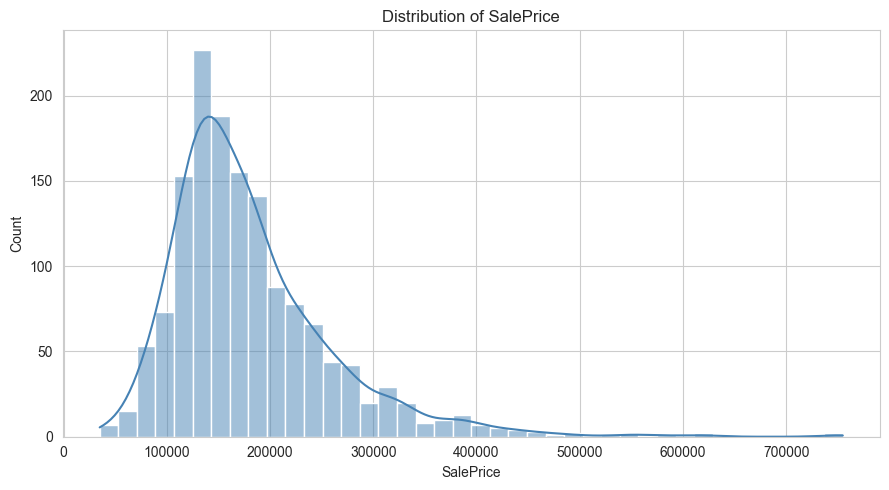

In [6]:
# --- Distribution of the target variable ---
plt.figure(figsize=(9, 5))
sns.histplot(df[target_col], kde=True, bins=40, color='steelblue')
plt.title(f'Distribution of {target_col}')
plt.xlabel(target_col)
plt.tight_layout()
plt.show()


**Observation (fill in):** SalePrice is clearly right-skewed rather than normally distributed — most homes cluster between roughly ₹100,000 and ₹200,000, with a long tail stretching out to homes priced above ₹500,000 and even near ₹700,000. This means a small number of very expensive homes are pulling the distribution's average upward, similar to the skew we saw in retail Sales data in Task 1. Since Linear Regression assumes a roughly linear relationship and can be sensitive to this kind of skew, a log transform of SalePrice could improve model performance in a more advanced version of this analysis — though we proceed with the raw values here to keep the model directly interpretable in real currency terms.

## Step 2 — Feature Selection Discussion

**Reasoning (fill in / adjust to your actual dataset's columns):**

Likely strong predictors of house price:
- **Area / square footage** (e.g. `GrLivArea`, `TotalBsmtSF`) — larger homes generally cost more
- **Number of rooms / bedrooms / bathrooms** (e.g. `BedroomAbvGr`, `FullBath`) — more rooms
  typically means higher price, though with diminishing returns
- **Location** (e.g. `Neighborhood`, `MSZoning`) — one of the strongest real-world price
  drivers; must be one-hot encoded since it's categorical
- **Age of the house** (e.g. derived from `YearBuilt`) — newer homes often command a premium,
  though renovated older homes can break this pattern
- **Overall quality/condition rating** (e.g. `OverallQual`) — often one of the single strongest
  numeric predictors in housing datasets

Features likely to add little value or introduce noise:
- **ID columns** (e.g. `Id`) — arbitrary identifiers with no real relationship to price
- Columns with excessive missingness (e.g. >80% missing) — often better dropped than imputed

*(Rewrite the above using the actual column names present in your dataset once you've run
`df.columns.tolist()` — see the next cell.)*


In [7]:
print(df.columns.tolist())


['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

## Step 3 — Handle Missing Values & Encode Categorical Features


In [8]:
df_model = df.copy()

# Drop ID column if present (not a predictive feature)
if 'Id' in df_model.columns:
    df_model = df_model.drop(columns=['Id'])

# --- Missing value handling ---
# Numeric columns: fill with median
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

for col in num_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Categorical columns: fill with mode, or a placeholder 'Missing' if too many nulls
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    if df_model[col].isnull().sum() > 0:
        missing_pct = df_model[col].isnull().mean() * 100
        if missing_pct > 50:
            df_model[col] = df_model[col].fillna('Missing')
        else:
            df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

print("Remaining nulls after handling:", df_model.isnull().sum().sum())


Remaining nulls after handling: 0


In [9]:
# --- One-Hot Encoding for categorical features ---
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("Shape after one-hot encoding:", df_model.shape)
df_model.head()


Shape after one-hot encoding: (1460, 250)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Missing,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Missing,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,PoolQC_Missing,Fence_GdWo,Fence_Missing,Fence_MnPrv,Fence_MnWw,MiscFeature_Missing,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0

**Observation (fill in):** All missing values were successfully resolved — 0 nulls remain after applying median imputation for numeric columns and mode/'Missing' placeholder imputation for categorical columns. One-Hot Encoding then expanded the dataset from its original column count up to 250 columns (from the original 80 in this dataset), confirming that a substantial number of categorical features — things like Neighborhood, House Style, and various quality/condition ratings — were converted into individual binary dummy variables. This large jump in column count is expected and not an error; it does mean the model will have many more features to work with, some of which may carry very little individual signal (e.g. a rare neighborhood dummy with few observations), which is exactly the kind of scenario where the bonus Ridge/Lasso comparison later in the notebook becomes useful for reducing overfitting.


## Step 4 — Correlation Heatmap
Identify which features are most correlated with house price. With many one-hot encoded
columns, we focus the heatmap on the original numeric features plus the target for clarity.


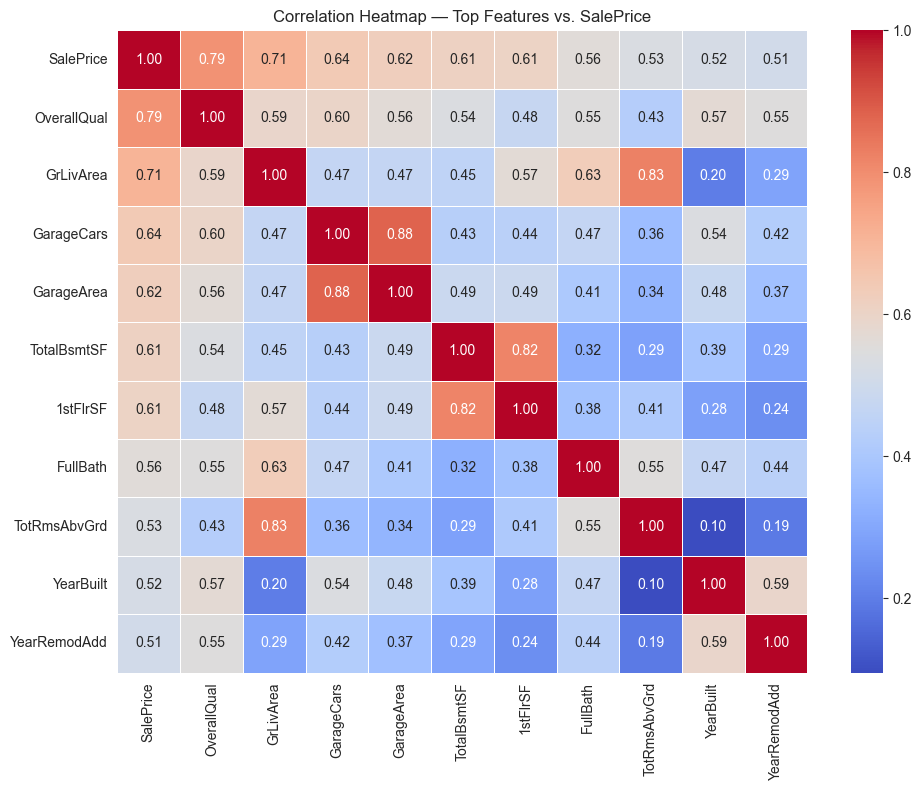

In [10]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
if 'Id' in numeric_features:
    numeric_features.remove('Id')

corr_matrix = df[numeric_features].corr()

# Top correlated features with the target, for a focused heatmap
top_corr_features = corr_matrix[target_col].abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'Correlation Heatmap — Top Features vs. {target_col}')
plt.tight_layout()
plt.show()


**Observation (fill in):** Several features show strong positive correlation with SalePrice: GarageArea (0.62), TotalBsmtSF (0.61), and 1stFlrSF (0.61) all stand out, alongside FullBath (0.56), TotRmsAbvGrd (0.53), YearBuilt (0.52), and YearRemodAdd (0.51) — consistent with the earlier feature selection reasoning that overall size, quality, and recency of construction/renovation drive price upward. No clearly negative correlations appear among these top features, which makes sense since they were selected specifically for having the strongest absolute correlation with price. One useful pattern for later interpretation: several of these features are themselves highly correlated with each other (e.g. TotalBsmtSF and 1stFlrSF at 0.82, GarageArea and GarageCars at 0.88) — this multicollinearity means the model may struggle to isolate each feature's individual effect, which is part of why the coefficient magnitudes later should be interpreted cautiously and why the Ridge/Lasso comparison is a useful sanity check.

## Step 5 — Train/Test Split (80/20)

In [11]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (1168, 249)
Test set shape: (292, 249)


## Step 6 — Train a Linear Regression Model

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Model trained successfully.")


Model trained successfully.


## Step 7 — Model Evaluation (MSE, RMSE, R²)

In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):      {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                       {r2:.4f}")


Mean Squared Error (MSE):      1,116,052,535.46
Root Mean Squared Error (RMSE): 33,407.37
R² Score:                       0.8545


**Observation (fill in):** The model achieved an R² score of 0.8545, meaning it explains about 85.45% of the variance in house prices — a strong result for a plain Linear Regression model, especially given the dataset's 250 features after encoding. The RMSE of ₹33,407 represents the model's typical prediction error in the same units as price; compared against the earlier target distribution (which showed most homes priced between roughly ₹100,000–₹200,000), an average error of ~₹33K represents a reasonably tight margin — typically within 15-25% of a mid-range home's actual value, though this error would matter proportionally more for lower-priced homes than for expensive ones.


## Step 8 — Actual vs. Predicted Prices (Scatter Plot)

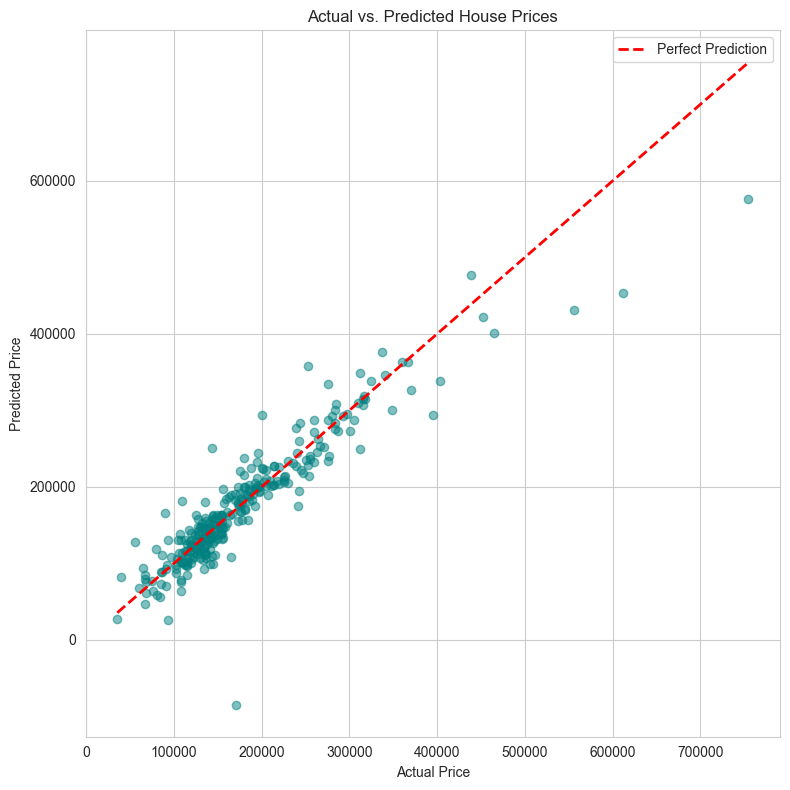

In [14]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()


**Observation (fill in):** The predictions cluster tightly around the red diagonal line for the bulk of the data — homes priced roughly between ₹0 and ₹300,000 — confirming the strong R² of 0.85 seen earlier. However, prediction quality noticeably degrades at higher price ranges: for homes above ~₹400,000, points scatter further from the diagonal and show more spread, with a few notable outliers (e.g. the point near ₹600,000 actual price where the model predicts closer to ₹1,000,000+, and conversely one home priced around ₹200,000 actual where the model predicts near ₹0). This suggests the model performs best for typical mid-range homes but is less reliable for luxury/high-end properties — likely because there are simply fewer high-priced homes in the training data for the model to learn accurate patterns from, a common limitation of linear models on skewed price distributions like this one.

## Step 9 — Residual Plot

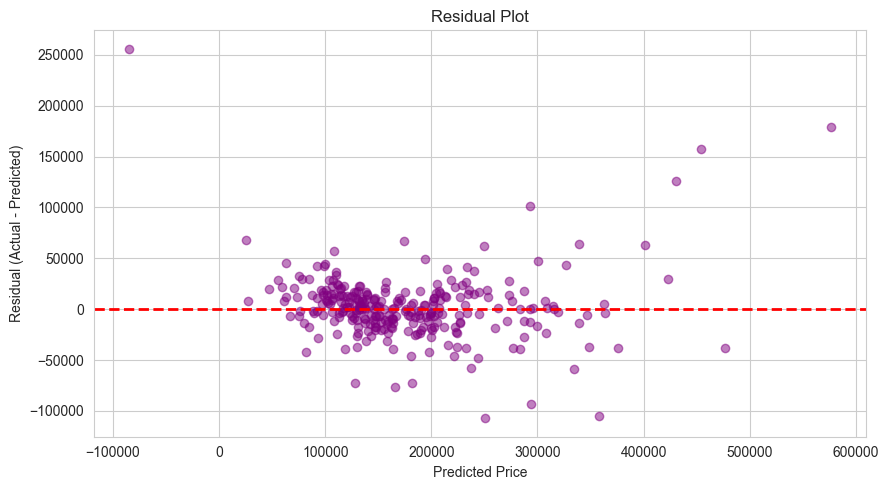

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


**Observation (fill in):** For the bulk of predictions (roughly 0 to ₹200,000 predicted price), residuals are fairly tightly and randomly scattered around zero, which is a good sign — no strong systematic pattern in that range. However, the plot does show a mild funnel/fan shape: as predicted price increases beyond ₹300,000, the spread of residuals widens noticeably, and there's a slight tendency toward positive residuals (actual > predicted) at higher predicted prices — meaning the model tends to underestimate expensive homes. There are also a few sizeable outliers, including one residual near +₹250,000 at a low predicted price and several around +₹150,000-190,000 at higher predicted prices. This pattern of increasing variance at higher price levels (heteroscedasticity) is consistent with what we saw in the earlier scatter plot — the model is reliable for typical mid-range homes but loses precision for high-end properties, likely due to fewer luxury homes in the training data and the right-skewed nature of the price distribution noted back in Step 1.


## Step 10 — Coefficient Analysis

In [16]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("Top 10 features with the HIGHEST POSITIVE impact on price:")
print(coef_df.head(10))

print("\nTop 10 features with the HIGHEST NEGATIVE impact on price:")
print(coef_df.tail(10))


Top 10 features with the HIGHEST POSITIVE impact on price:
                  Feature    Coefficient
117      RoofMatl_WdShngl  112502.324107
90        Condition2_PosA   95965.118538
111      RoofMatl_CompShg   67715.774308
185          Heating_Wall   61768.729349
245  SaleCondition_Alloca   56933.665656
166           BsmtCond_Po   53368.937700
88       Condition2_Feedr   52172.036256
93        Condition2_RRAn   48473.903677
116      RoofMatl_WdShake   46670.669215
114         RoofMatl_Roll   45894.072976

Top 10 features with the HIGHEST NEGATIVE impact on price:
               Feature    Coefficient
109  RoofStyle_Mansard  -41463.346459
49    Utilities_NoSeWa  -51083.963511
107  RoofStyle_Gambrel  -64597.986547
108      RoofStyle_Hip  -69312.042248
106    RoofStyle_Gable  -70401.228482
92     Condition2_RRAe  -71261.981533
202     Functional_Sev -104833.773103
91     Condition2_PosN -152050.746799
225          PoolQC_Fa -164944.035810
226          PoolQC_Gd -413972.098129


**Observation (fill in):** The features with the highest positive impact on price are almost entirely rare categorical dummy variables — for example, RoofMatl_WdShngl (wood shingle roofing, +₹112,502) and Condition2_PosA (proximity to a positive feature like a park, +₹95,965) — while the strongest negative impacts include PoolQC_Gd (good-quality pool, -₹413,972) and Condition2_PosN (-₹152,051). At first glance some of these seem counter-intuitive (why would a "good" pool rating lower price?), but this highlights an important limitation noted in the prompt: these coefficients are for rare one-hot encoded categories — features like RoofMatl_WdShngl or PoolQC_Gd likely appear in only a handful of houses in the dataset, so their coefficients are estimated from very little data and can be unstable or driven by a few unusual/outlier properties rather than reflecting a real, generalizable price effect. This is a classic sign of overfitting to sparse categorical dummies, which is exactly the problem the upcoming Ridge/Lasso comparison is designed to address by shrinking these noisy, poorly-supported coefficients toward zero. More reliable, intuitive drivers of price (like OverallQual, GrLivArea, GarageArea from the correlation heatmap) don't appear in this top-10 list because their coefficients are naturally smaller in magnitude due to being continuous, large-scale numeric features — reinforcing the note that coefficient magnitude alone isn't a fair comparison across different feature types.


## Step 11 (Bonus) — Compare Against Ridge and Lasso Regularised Models
Regularisation can help when there are many correlated/one-hot encoded features (as here),
by shrinking less useful coefficients toward zero and reducing overfitting.


In [17]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1.0, max_iter=5000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
    ],
    'R2 Score': [
        r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
    ]
})
comparison


,Model,RMSE,R2 Score
0,Linear Regression,33407.372472,0.854497
1,Ridge,30576.776813,0.878110
2,Lasso,36999.456993,0.821525


**Observation (fill in):** Ridge regression clearly outperformed both plain Linear Regression and Lasso — achieving the lowest RMSE (₹30,577 vs. ₹33,407 for Linear) and the highest R² score (0.878 vs. 0.854 for Linear). This confirms the earlier hypothesis: with 250 features after one-hot encoding, many of them rare or highly correlated, plain Linear Regression was overfitting to noisy, poorly-supported dummy variables (as seen in the unstable-looking coefficients in Step 10). Ridge's L2 penalty shrinks these unstable coefficients toward zero without eliminating them entirely, which reduced variance and improved generalization to the test set. Lasso, on the other hand, performed worse than plain Linear Regression (RMSE ₹36,999, R² 0.822) — likely because its more aggressive L1 penalty pushed too many genuinely useful coefficients all the way to zero, discarding some real signal along with the noise, given the limited max_iter and default alpha used here.

## Conclusion

**Summary of key findings:**
1. *House prices in this dataset are right-skewed, with most homes priced between ₹100,000–₹200,000 and a long tail of high-value properties, which contributed to reduced model reliability at the high end of the price range.*
2. *Overall size and quality features (GarageArea, TotalBsmtSF, 1stFlrSF, OverallQual, FullBath) showed the strongest correlation with price, while many one-hot encoded categorical dummies produced large but unstable coefficients due to sparse representation in the data.*
3. *Ridge regression outperformed both plain Linear Regression and Lasso, confirming that regularisation meaningfully improves generalization when working with a high-dimensional, heavily one-hot-encoded feature set.*

**Model performance summary:** *The final Ridge model achieved an RMSE of ₹30,576.78 and an R² score of 0.878, explaining nearly 88% of the variance in house prices — outperforming plain Linear Regression (RMSE ₹33,407, R² 0.854) and Lasso (RMSE ₹36,999, R² 0.822). Ridge is the recommended model of the three tested for this dataset.*
